# Performing Molecular Dynamics (v3+)

> ### In this tutorial we will cover:
> - The all-in-Python route — parametrizing directly with the OpenFF SMIRNOFF force field using BuildAMol's `openff_md` extension (no external tools required)

If you have tried using BuildAMol with Molecular Dynamics in the past you will likely have checked out the previous tutorial, which outlined out to use BuildAMol in conjunction with CHARMM-Gui and OpenMM. 

As of BuildAMol `v1.3` we now have a streamlined pipeline using [OpenFF](https://openforcefield.org) and their [SMIRNOFF](https://openforcefield.github.io/standards/standards/smirnoff/) force field family that allows us to assign force field parameters and partial charges directly from the molecular graph (via SMILES), so there are no pre-computed parameter files from external tools to manage. The system created is the same OpenMM system as previously.

So, with that being said, let's dive into the new MD-pipeline from BuildAMol. We begin again by building the same molecule as we did in the original tutorial.

## Building a Molecule

Let's start by making some molecule that we can study...

In [1]:
import buildamol as bam
bam.utils.visual.set_backend("py3Dmol")

bam.load_small_molecules()

benzene = bam.get_compound("benzene")
amine = bam.get_compound("dimethylamine")

amine.autolabel()
benzene.autolabel()

Molecule(BNZ)

In [2]:
# make a molecule
# (btw. if you are unfamiliar with the % and @ syntax, check out the syntax-tutorial)
link = bam.linkage(None, "C1")

mol = benzene.copy()
for C in benzene.get_atoms(1, 3, 5):
    link.atom1 = C
    mol = mol % link @ 1 + amine

link.atom1 = link.atom2 = "C2"

mol2 = mol.copy()
for amine_residue in mol.get_residues("DMN"):
    mol = mol % link @ amine_residue.serial_number + mol2.copy() @ 2
    
mol.optimize()
mol.show()

You appear to be running in JupyterLab (or JavaScript failed to load for some other reason). You need to install the 3dmol extension: 
 jupyter labextension install jupyterlab_3dmol

## Parametrizing the molecule

Where previously we saved the molecule to a file, went to the CHARMM-Gui webserver and got a PSF file from there, we now simply import the `openff_md` and use its API to obtain the force field parameters.

In [3]:
from buildamol.extensions.molecular_dynamics import openff_md as offmd

A single call to `parametrize` handles everything — converting the molecule to an OpenFF topology, assigning partial charges, and creating the OpenMM `System`:

The default force field is [OpenFF 2.x (Sage)](https://openforcefield.org) with MMFF94 partial charges (computed via RDKit, no extra dependencies). For production simulations the OpenFF-recommended charges are `am1bccelf10`, which require AmberTools or OpenEye to be installed:

```python
# Best accuracy — requires AmberTools or OpenEye
system = offmd.parametrize(mol, charge_method="am1bccelf10")

# Fastest option — no extra dependencies
system = offmd.parametrize(mol, charge_method="gasteiger")
```

In [4]:
system = offmd.parametrize(mol, charge_method="gasteiger")

/Users/noahhk/anaconda3/envs/glyco2/lib/python3.11/site-packages/ipywidgets/widgets/widget.py:438: DeprecationWarning: The `ipykernel.comm.Comm` class has been deprecated. Please use the `comm` module instead.For creating comms, use the function `from comm import create_comm`.
  self.comm = Comm(**args)


The default force field is [OpenFF 2.x (Sage)](https://openforcefield.org) with AM1-BCC-ELF10 partial charges — both can be swapped out if needed:

```python
# Use a specific force field or faster (less accurate) Gasteiger charges for quick tests
system = offmd.parametrize(mol, force_field="openff-2.1.0.offxml", charge_method="gasteiger")
```

In [5]:
# let's start by checking the potential energy of the system
system.minimize()
print(f"Potential energy after minimization: {system.get_energy():.2f} kJ/mol")
minimized_mol = system.to_molecule()
minimized_mol.show()   

Potential energy after minimization: 304.18 kJ/mol


You appear to be running in JupyterLab (or JavaScript failed to load for some other reason). You need to install the 3dmol extension: 
 jupyter labextension install jupyterlab_3dmol

With a minimized structure in hand, running a short MD trajectory is one more method call:

In [6]:
# Run 100000 steps of MD
# The reporter argument writes step, energy and temperature to a CSV file
system.run(100000, reporter="files/molecule_openff_MD.csv", report_interval=50)

<Axes: xlabel='Step'>

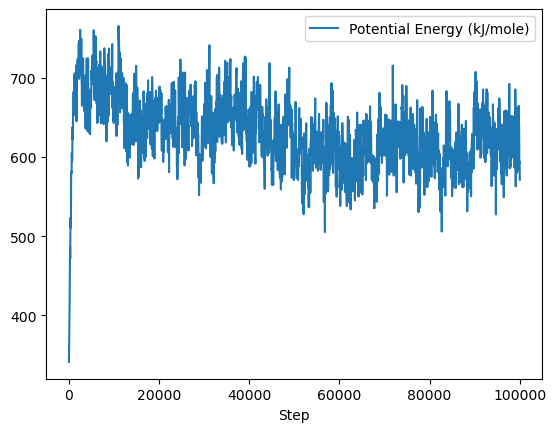

In [7]:
import pandas as pd
df = pd.read_csv("files/molecule_openff_MD.csv")
df.plot.line(x="Step", y="Potential Energy (kJ/mole)")

Once the simulation is done we can either write the current positions to a PDB file, or pull them back into BuildAMol as a `Molecule` to keep working with the relaxed structure:

In [8]:
# Save the final structure to a PDB file for external analysis
# system.save_pdb("files/molecule_openff_MD.pdb")

# Or bring the coordinates back into BuildAMol to continue working with them
mol_relaxed = system.to_molecule()
mol_relaxed.show()

You appear to be running in JupyterLab (or JavaScript failed to load for some other reason). You need to install the 3dmol extension: 
 jupyter labextension install jupyterlab_3dmol

All method calls on `OpenMMSystem` return `self`, so the whole workflow can be written as one chain if preferred:

```python
(offmd.parametrize(mol)
    .minimize()
    .run(10_000, reporter="md_log.csv")
    .save_pdb("final.pdb")
)
```

And that's the complete story — a BuildAMol molecule to a finished MD simulation without leaving Python or touching any external tools.

That's it for this time, thanks a lot for checking out this tutorial and good luck with your project using BuildAMol!